# Line Chart - Fatalities Over Time

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

## Myanmar

In [36]:
# ACLED data path
# https://data.humdata.org/dataset/myanmar-acled-conflict-data
acled_path = "../data/ACLED/"
df_myanmar = pd.read_csv(acled_path + "myanmar_political_violence_events_and_fatalities_by_month-year_as-of-21jan2026.csv", sep=";")
df_myanmar.head()

,Country,Admin1,Admin2,ISO3,Admin2 Pcode,Admin1 Pcode,Month,Year,Events,Fatalities
0,Myanmar,Ayeyarwady,Myaungmya,MMR,MMR017D003,MMR017,January,2010,0,0
1,Myanmar,Chin,Matupi,MMR,MMR004D004,MMR004,January,2010,0,0
2,Myanmar,Magway,Magway,MMR,MMR009D001,MMR009,January,2010,0,0
3,Myanmar,Magway,Minbu,MMR,MMR009D002,MMR009,January,2010,0,0
4,Myanmar,Sagaing,Hkamti,MMR,MMR005D008,MMR005,January,2010,0,0


In [37]:
# Myanmar Fatalities Over Time
# Filter for Year >= 2015
df_myanmar = df_myanmar[df_myanmar["Year"] >= 2015]
# Create a date column, combining Year and Month
df_myanmar["Date"] = pd.to_datetime(df_myanmar["Year"].astype(str) + "-" + df_myanmar["Month"].astype(str) + "-01", format="%Y-%B-%d")

# Group by date and sum Fatalities, then normalize column names for plotting
df_myanmar_fatalities = df_myanmar.groupby("Date")["Fatalities"].sum().reset_index()
df_myanmar_fatalities.rename(columns={"Date": "date", "Fatalities": "fatalities"}, inplace=True)

Text(0.5, 1.0, 'Myanmar Fatalities Over Time')

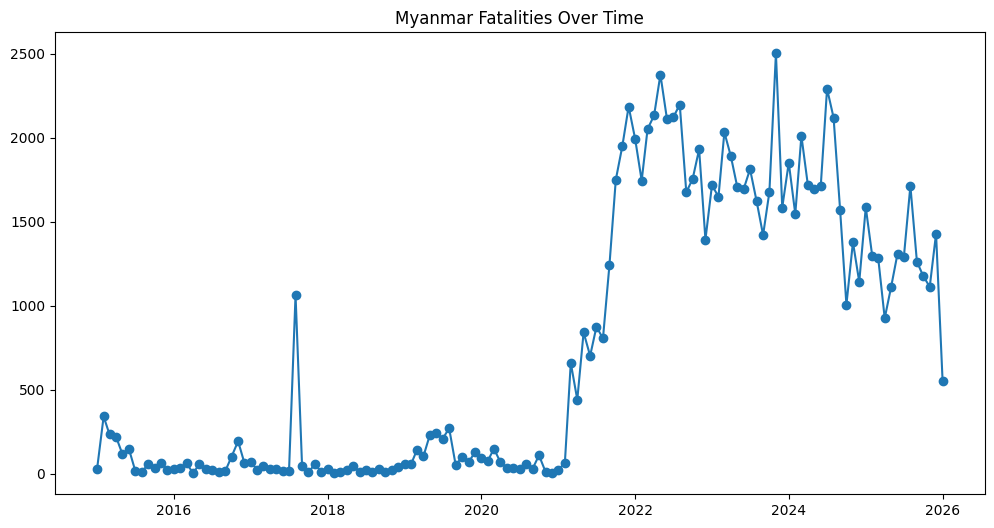

In [38]:
# Plot the line chart
plt.figure(figsize=(12, 6))
plt.plot(df_myanmar_fatalities["date"], df_myanmar_fatalities["fatalities"], marker='o')
plt.title("Myanmar Fatalities Over Time")

### Myanmar Events to notes:
- Rohingya genocide(2016-2017): https://en.wikipedia.org/wiki/Rohingya_genocide
- Military coup(2021): https://en.wikipedia.org/wiki/2021_Myanmar_coup_d%27%C3%A9tat
- Ongoing civil conflict: https://en.wikipedia.org/wiki/Internal_conflict_in_Myanmar

## Burkina Faso

In [39]:
# https://data.humdata.org/dataset/burkina-faso-acled-conflict-data
df_burkina = pd.read_csv(acled_path + "burkina-faso_political_violence_events_and_fatalities_by_month-year_as-of-21jan2026.csv", sep=";")
df_burkina.head()

,Country,Admin1,Admin2,ISO3,Admin2 Pcode,Admin1 Pcode,Month,Year,Events,Fatalities
0,Burkina Faso,Plateau-Central,Oubritenga,BFA,BF5503,BF55,January,1997,0,0
1,Burkina Faso,Centre-Est,Kourittenga,BFA,BF4803,BF48,January,1997,0,0
2,Burkina Faso,Boucle du Mouhoun,Kossi,BFA,BF4603,BF46,January,1997,0,0
3,Burkina Faso,Centre-Ouest,Sissili,BFA,BF5003,BF50,January,1997,0,0
4,Burkina Faso,Centre-Ouest,Boulkiemde,BFA,BF5001,BF50,January,1997,0,0


In [40]:
# Burkina Faso Fatalities Over Time
# Filter for Year >= 2015
df_burkina = df_burkina[df_burkina["Year"] >= 2015]
# Create a date column, combining Year and Month
df_burkina["Date"] = pd.to_datetime(df_burkina["Year"].astype(str) + "-" + df_burkina["Month"].astype(str) + "-01", format="%Y-%B-%d")
# Group by date and sum Fatalities, then normalize column names for plotting
df_burkina_fatalities = df_burkina.groupby("Date")["Fatalities"].sum().reset_index()

Text(0.5, 1.0, 'Myanmar Fatalities Over Time')

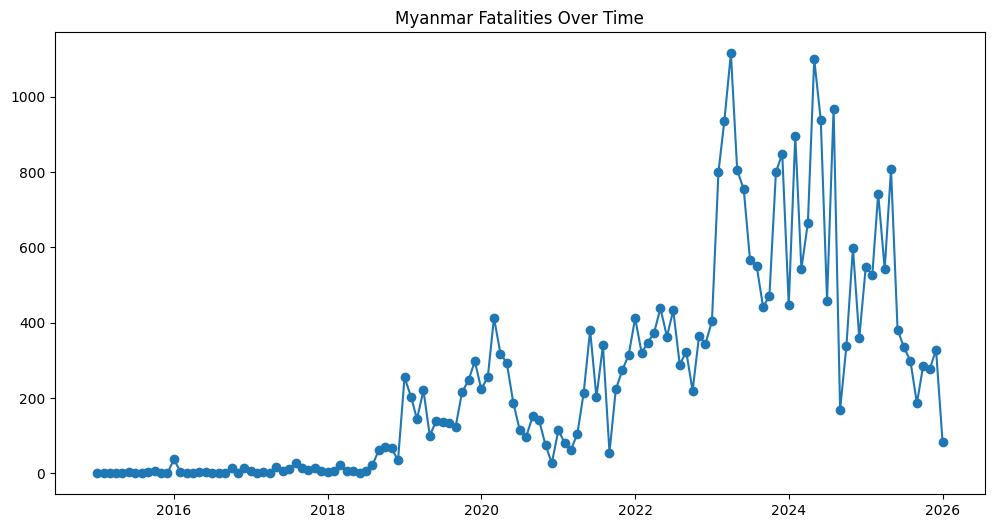

In [41]:
# Plot the line chart
plt.figure(figsize=(12, 6))
plt.plot(df_burkina_fatalities["Date"], df_burkina_fatalities["Fatalities"], marker='o')
plt.title("Myanmar Fatalities Over Time")

### Burkina Faso Events to notes:
- Jihadist insurgency (2015–2023): https://en.wikipedia.org/wiki/Jihadist_insurgency_in_Burkina_Faso
- Coup d'état (January 2022): https://en.wikipedia.org/wiki/January_2022_Burkina_Faso_coup_d%27%C3%A9tat
- Coup d'état (September 2022): https://en.wikipedia.org/wiki/September_2022_Burkina_Faso_coup_d%27%C3%A9tat

In [42]:
# Save datasets to CSV
save_path = "../data/processed/"
df_myanmar_fatalities.to_csv(save_path + "myanmar_fatalities_over_time.csv", index=False)
df_burkina_fatalities.to_csv(save_path + "burkina_faso_fatalities_over_time.csv", index=False)